<a href="https://colab.research.google.com/github/asegura4488/EDCO_IntroCienciaDatos/blob/main/Semana2/Sesion4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [5]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
ruta = "/content/drive/MyDrive/EDCO_IntroCienciaDatos/Semana2"
os.chdir(ruta)
print(os.getcwd())

/content/drive/MyDrive/EDCO_IntroCienciaDatos/Semana2


In [9]:
!ls

BaseDatos  Datos  Sesion3.ipynb  Sesion4.ipynb


In [16]:
# Necesitamos leer varios archivos que tiene una jerarquia de arbol
# Lectura inteligente de archivos
csv_files = sorted(
    glob.glob( os.path.join("BaseDatos","**","*.csv"), recursive=True )
)

In [17]:
print(len(csv_files))
print(csv_files)

20
['BaseDatos/Proceso_1/muestra.csv', 'BaseDatos/Proceso_10/muestra.csv', 'BaseDatos/Proceso_2/muestra.csv', 'BaseDatos/Proceso_3/muestra.csv', 'BaseDatos/Proceso_4/muestra.csv', 'BaseDatos/Proceso_5/muestra.csv', 'BaseDatos/Proceso_6/muestra.csv', 'BaseDatos/Proceso_7/muestra.csv', 'BaseDatos/Proceso_8/muestra.csv', 'BaseDatos/Proceso_9/muestra.csv', 'BaseDatos/Proceso_Header_1/muestra.csv', 'BaseDatos/Proceso_Header_10/muestra.csv', 'BaseDatos/Proceso_Header_2/muestra.csv', 'BaseDatos/Proceso_Header_3/muestra.csv', 'BaseDatos/Proceso_Header_4/muestra.csv', 'BaseDatos/Proceso_Header_5/muestra.csv', 'BaseDatos/Proceso_Header_6/muestra.csv', 'BaseDatos/Proceso_Header_7/muestra.csv', 'BaseDatos/Proceso_Header_8/muestra.csv', 'BaseDatos/Proceso_Header_9/muestra.csv']


In [19]:
# Queremos hacer un filtrado, for por comprension
csv_files = [ f for f in csv_files if "Proceso_Header" in f ]
csv_files

['BaseDatos/Proceso_Header_1/muestra.csv',
 'BaseDatos/Proceso_Header_10/muestra.csv',
 'BaseDatos/Proceso_Header_2/muestra.csv',
 'BaseDatos/Proceso_Header_3/muestra.csv',
 'BaseDatos/Proceso_Header_4/muestra.csv',
 'BaseDatos/Proceso_Header_5/muestra.csv',
 'BaseDatos/Proceso_Header_6/muestra.csv',
 'BaseDatos/Proceso_Header_7/muestra.csv',
 'BaseDatos/Proceso_Header_8/muestra.csv',
 'BaseDatos/Proceso_Header_9/muestra.csv']

In [20]:
# Entender el procesado sobre 1 archivo
# Posteriormente automatizar

In [21]:
archivo = csv_files[0]
archivo

'BaseDatos/Proceso_Header_1/muestra.csv'

In [22]:
# Leer archivo de csv usand pandas
df = pd.read_csv(archivo, sep=',', low_memory=False)

In [23]:
df.head()

,fecha reporte web,ID de caso,Fecha de notificación,Código DIVIPOLA departamento,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,...,Código ISO del país,Nombre del país,Recuperado,Fecha de inicio de síntomas,Fecha de muerte,Fecha de diagnóstico,Fecha de recuperación,Tipo de recuperación,Pertenencia étnica,Nombre del grupo étnico
0,2022-01-12 00:00:00,"5,399,804",2022-01-10 00:00:00,5,ANTIOQUIA,"5,001",MEDELLIN,45,1,F,...,NaN,NaN,Recuperado,2022-01-06 00:00:00,NaN,2022-01-10 00:00:00,2022-01-20 00:00:00,Tiempo,6,NaN
1,2022-01-16 00:00:00,"5,520,445",2022-01-02 00:00:00,73,TOLIMA,"73,001",IBAGUE,44,1,F,...,NaN,NaN,Recuperado,2021-12-30 00:00:00,NaN,2022-01-13 00:00:00,2022-01-17 00:00:00,Tiempo,6,NaN
2,2021-12-30 00:00:00,"5,141,954",2021-12-27 00:00:00,11,BOGOTA,"11,001",BOGOTA,30,1,F,...,NaN,NaN,Recuperado,2021-12-27 00:00:00,NaN,2021-12-28 00:00:00,2022-01-10 00:00:00,Tiempo,6,NaN
3,2021-06-10 00:00:00,"3,642,260",2021-06-08 00:00:00,85,CASANARE,"85,001",YOPAL,71,1,M,...,NaN,NaN,Recuperado,2021-05-24 00:00:00,NaN,2021-06-08 00:00:00,2021-06-11 00:00:00,Tiempo,6,NaN
4,2020-12-24 00:00:00,"1,551,989",2020-12-22 00:00:00,11,BOGOTA,"11,001",BOGOTA,48,1,F,...,NaN,NaN,Recuperado,2020-12-12 00:00:00,NaN,2020-12-22 00:00:00,2021-01-06 00:00:00,Tiempo,6,NaN


In [24]:
# Ver la dimension de los datos
df.shape

(300, 23)

In [28]:
# Si quieremos las features disponibles
features = df.columns.tolist()
len(features)

23

In [29]:
features

['fecha reporte web',
 'ID de caso',
 'Fecha de notificación',
 'Código DIVIPOLA departamento',
 'Nombre departamento',
 'Código DIVIPOLA municipio',
 'Nombre municipio',
 'Edad',
 'Unidad de medida de edad',
 'Sexo',
 'Tipo de contagio',
 'Ubicación del caso',
 'Estado',
 'Código ISO del país',
 'Nombre del país',
 'Recuperado',
 'Fecha de inicio de síntomas',
 'Fecha de muerte',
 'Fecha de diagnóstico',
 'Fecha de recuperación',
 'Tipo de recuperación',
 'Pertenencia étnica',
 'Nombre del grupo étnico']

In [31]:
# Vamos a crear una tabla independiente para modificar
sub = df[['Edad','Nombre departamento']].copy()
sub

,Edad,Nombre departamento
0,45,ANTIOQUIA
1,44,TOLIMA
2,30,BOGOTA
3,71,CASANARE
4,48,BOGOTA
...,...,...
295,30,BOGOTA
296,6,ANTIOQUIA
297,35,SANTANDER
298,7,BOGOTA


In [33]:
# Será que los datos están "sucios", Valores no asignados
sub.isna().sum()

,0
Edad,0
Nombre departamento,0


In [35]:
sub.dtypes

,0
Edad,int64
Nombre departamento,object


In [36]:
# Vamos realmente a convertir la edad en numeros
sub['Edad'] = pd.to_numeric( sub['Edad'] )

In [38]:
sub.dtypes

,0
Edad,int64
Nombre departamento,object


In [39]:
# Borrar espacios innecesario en los nombres del departamento
sub['Nombre departamento'] = sub['Nombre departamento'].astype('string').str.strip()

In [40]:
sub

,Edad,Nombre departamento
0,45,ANTIOQUIA
1,44,TOLIMA
2,30,BOGOTA
3,71,CASANARE
4,48,BOGOTA
...,...,...
295,30,BOGOTA
296,6,ANTIOQUIA
297,35,SANTANDER
298,7,BOGOTA


In [49]:
sub['Edad'].describe()

,Edad
count,300.000000
mean,41.933333
std,19.511995
min,2.000000
25%,28.000000
50%,40.000000
75%,53.250000
max,101.000000


Text(0, 0.5, 'Frecuencia')

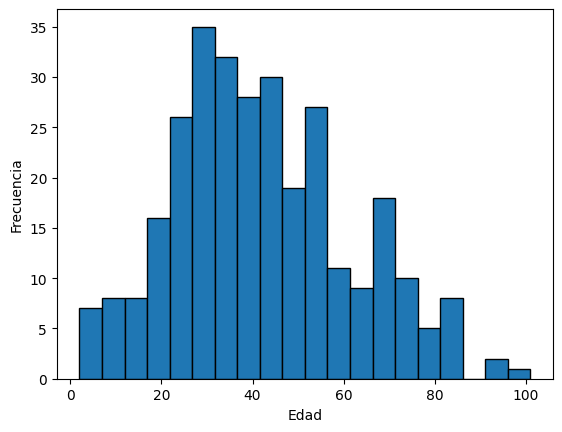

In [53]:
# Visualizamos
# Distribucion de datos empirica
sub['Edad'].plot.hist(bins=20, edgecolor='black')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

In [56]:
# Una segmentacion por departamento
# Agrupamiento por clase
conteo_departamento = sub['Nombre departamento'].value_counts()
#conteo_departamento

<Axes: ylabel='Nombre departamento'>

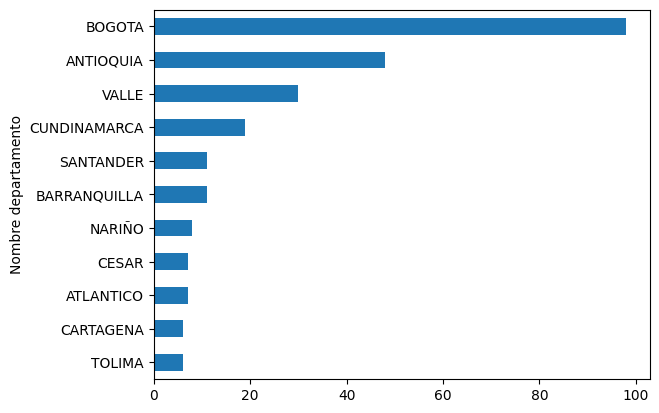

In [58]:
# Entregar el grafico de contagios en los 10 departamentos más importantes
conteo_departamento.head(11).sort_values().plot.barh()